In [129]:
import pandas as pd 
import numpy as np 
import sklearn as sk
import seaborn as sns
import os 
import pandas as pd
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import MaxAbsScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
import os
os.environ["OMP_NUM_THREADS"] = "2"
os.environ["OPENBLAS_NUM_THREADS"] = "2"
os.environ["MKL_NUM_THREADS"] = "2"

In [130]:
data_path='/mnt/cold2/snaketree/prj/PPH/local/share/data/saver_mat'
train_id=['CRC1502','CRC1620','CRC1139']
tratt_cercato=['cetux','CTX72h']
train=pd.DataFrame()
for file in os.listdir(data_path):
    sample_name=str.split(file,sep='_')[4]
    trattamento=str.split(file,sep='_')[5]
    if sample_name in train_id and trattamento in tratt_cercato:
        print(file)
        data=pd.read_csv(os.path.join(data_path,file),header=0,index_col=0)
        data=data.T
        data['sample']=sample_name
        data['cell_id']=data.index
        data['trattamento']=trattamento
        data.reset_index(drop=True,inplace=True)
        train=pd.concat([train,data])

filtered_annotated_saver_ribomito_CRC1502_cetux_1_log2_pc1_cpm.csv
filtered_annotated_saver_ribomito_CRC1139_cetux_1_log2_pc1_cpm.csv
filtered_annotated_saver_ribomito_CRC1620_cetux_1_log2_pc1_cpm.csv


In [131]:
from func_NT_cetux import *
df=train
df_clean, dup = strip_prefix_from_genes(df, meta_cols=("cell_id","sample","trattamento"), sep=":", on_duplicate="first")
hvg=pd.read_csv('bbknn_cetux_KRAS/npcs=20__nwb=3__trim=None__res=0.3/highly_variable_genes.csv',header=0,index_col=False)
to_keep=list(hvg['gene'])
to_keep = to_keep + ['sample', 'cell_id', 'trattamento']
df_clean = df_clean.loc[:,to_keep]
clu_path='bbknn_cetux_KRAS/npcs=20__nwb=3__trim=None__res=0.3/obs_data_with_umap.csv'
meta_data=pd.read_csv(clu_path,header=0)
df_clean['uid']=df_clean['sample']+df_clean['trattamento']+'|'+df_clean['cell_id']+'|'+df_clean['trattamento']
label=meta_data.loc[:,['uid','leiden_r0.3']]
label=label.rename(columns={'leiden_r0.3':'cluster'})
merged_df = df_clean.merge(label, on='uid', how='inner')
meta_cols = ['uid','sample','cell_id','trattamento','cluster']
feature_cols = [c for c in merged_df.columns if c not in meta_cols]  # geni/features numeriche


In [132]:
X = merged_df[feature_cols].copy()
y = merged_df['cluster'].copy()


X.index = merged_df['uid']
y.index = merged_df['uid']


groups = merged_df.set_index('uid')['sample']  
use_group_split = False  # metti True se vuoi split per sample

if use_group_split:
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups=groups))
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
else:

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

In [133]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import MaxAbsScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

meta_cols = ['uid','sample','cell_id','trattamento','cluster']
feature_cols = [c for c in merged_df.columns if c not in meta_cols]

X = merged_df[feature_cols].copy()
y = merged_df['cluster'].copy()
samples = merged_df['sample'].copy()

# indicizza tutto per uid (comodo per .loc)
X.index = merged_df['uid'].values
y.index = merged_df['uid'].values
samples.index = merged_df['uid'].values

print("KRAS+cetux cells:", X.shape[0], "features:", X.shape[1])
print("Samples:", samples.unique())
print("Cluster counts:\n", y.value_counts().sort_index())


KRAS+cetux cells: 12947 features: 1500
Samples: ['CRC1502' 'CRC1139' 'CRC1620']
Cluster counts:
 cluster
0    2988
1    2450
2    1995
3    1886
4    1701
5    1406
6     521
Name: count, dtype: int64


In [134]:
def margin_score(probs: np.ndarray) -> np.ndarray:
    p_sorted = np.sort(probs, axis=1)
    return p_sorted[:, -1] - p_sorted[:, -2]

def pick_tau_for_risk(scores: np.ndarray, err: np.ndarray,
                      risk_target: float = 0.05,
                      min_coverage: float = 0.2):
    taus = np.unique(scores)[::-1]
    best_tau, best_cov = None, -1.0
    for t in taus:
        m = scores >= t
        if m.sum() == 0:
            continue
        cov = m.mean()
        if cov < min_coverage:
            continue
        risk = err[m].mean()
        if risk <= risk_target and cov > best_cov:
            best_tau, best_cov = float(t), float(cov)
    return best_tau, best_cov


In [135]:
rf_params = dict(
    random_state=42,
    n_jobs=3,
    max_depth=None,
    max_features='log2',
    min_samples_split=2,
    n_estimators=300
)

unique_samples = samples.unique()

taus = []
fold_summary = []
cell_level = [] 
def entropy(probs, eps=1e-12):
    p = np.clip(probs, eps, 1.0)
    return -(p * np.log(p)).sum(axis=1)

for holdout in unique_samples:
    tr_idx = samples != holdout
    va_idx = samples == holdout

    X_tr, y_tr = X.loc[tr_idx], y.loc[tr_idx]
    X_va, y_va = X.loc[va_idx], y.loc[va_idx]

    scaler = MaxAbsScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_va_s = scaler.transform(X_va)

    rf = RandomForestClassifier(**rf_params)
    rf.fit(X_tr_s, y_tr)

    probs_va = rf.predict_proba(X_va_s)
    pred_va = probs_va.argmax(axis=1)

    scores_va = margin_score(probs_va)
    err_va = (pred_va != y_va.values).astype(int)

    tau, cov = pick_tau_for_risk(scores_va, err_va, risk_target=0.05, min_coverage=0.2)

    if tau is None:

        tau = float(np.quantile(scores_va, 0.30))
        cov = float((scores_va >= tau).mean())

    risk = float(err_va[scores_va >= tau].mean())

    taus.append(tau)
    fold_summary.append((holdout, tau, cov, risk))

    print(f"Holdout {holdout}: tau={tau:.4f}, coverage={cov:.3f}, risk={risk:.3f}")
    probs_va = rf.predict_proba(X_va_s)
    pred_va = probs_va.argmax(axis=1)

    scores_va = margin_score(probs_va)   # margin
    maxp_va = probs_va.max(axis=1)
    H_va = entropy(probs_va)
    Hn_va = H_va / np.log(probs_va.shape[1])

    err_va = (pred_va != y_va.values).astype(int)

    # tau, cov = pick_tau_for_risk(scores_va, err_va, risk_target=0.01, min_coverage=0.2)
    # if tau is None:
    #     tau = float(np.quantile(scores_va, 0.30))

    accepted_va = scores_va >= tau
    correct_va = pred_va == y_va.values

    # salva per-cellula SOLO del holdout sample
    tmp = pd.DataFrame({
        "uid": X_va.index,
        "holdout": holdout,
        "y_true": y_va.values,
        "y_pred": pred_va,
        "margin": scores_va,
        "max_prob": maxp_va,
        "H_norm": Hn_va,
        "accepted": accepted_va,
        "correct": correct_va
    }).set_index("uid")

    cell_level.append(tmp)
    
df_cells = pd.concat(cell_level, axis=0)
df_cells.head()

tau_final = float(np.median(taus))
print("\nFinal tau (median across folds):", tau_final)
df_folds = pd.DataFrame(fold_summary, columns=["holdout","tau","coverage","risk"])
df_folds = df_folds.sort_values("holdout")

tau_med = np.median(df_folds["tau"])
print(df_folds)
print("tau_med:", tau_med)

Holdout CRC1502: tau=0.0767, coverage=0.853, risk=0.049
Holdout CRC1139: tau=0.1133, coverage=0.756, risk=0.049
Holdout CRC1620: tau=0.0567, coverage=0.898, risk=0.049

Final tau (median across folds): 0.07666666666666669
   holdout       tau  coverage      risk
1  CRC1139  0.113333  0.756198  0.049180
0  CRC1502  0.076667  0.852924  0.048824
2  CRC1620  0.056667  0.897922  0.049330
tau_med: 0.07666666666666669


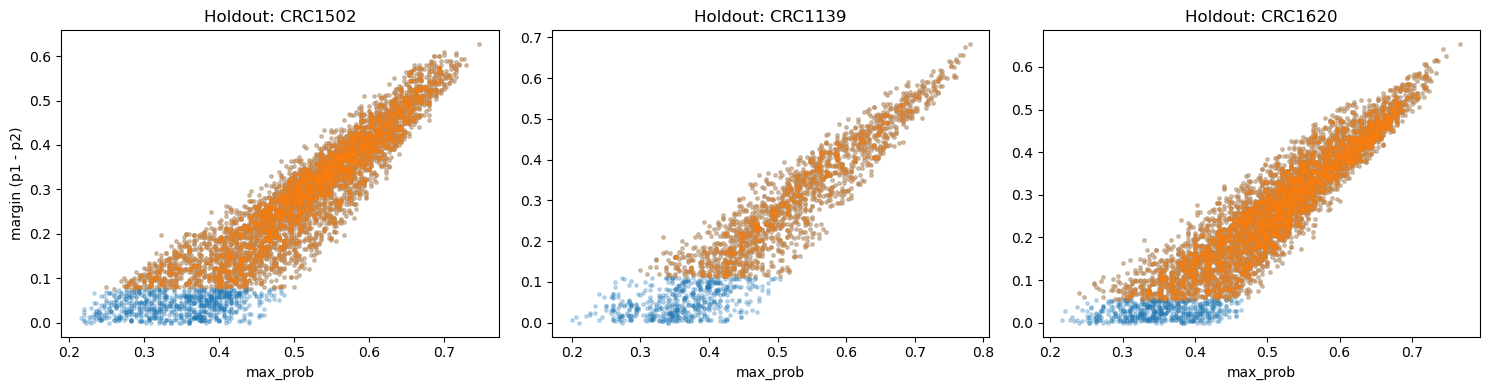

In [136]:
import matplotlib.pyplot as plt

holdouts = df_cells["holdout"].unique()
fig, axes = plt.subplots(1, len(holdouts), figsize=(5*len(holdouts), 4), sharex=False, sharey=False)

if len(holdouts) == 1:
    axes = [axes]

for ax, h in zip(axes, holdouts):
    d = df_cells[df_cells["holdout"] == h]
    ax.scatter(d["max_prob"], d["margin"], s=6, alpha=0.25)
    ax.scatter(d.loc[d["accepted"], "max_prob"], d.loc[d["accepted"], "margin"], s=6, alpha=0.25)
    ax.set_title(f"Holdout: {h}")
    ax.set_xlabel("max_prob")
axes[0].set_ylabel("margin (p1 - p2)")
plt.tight_layout()
plt.show()


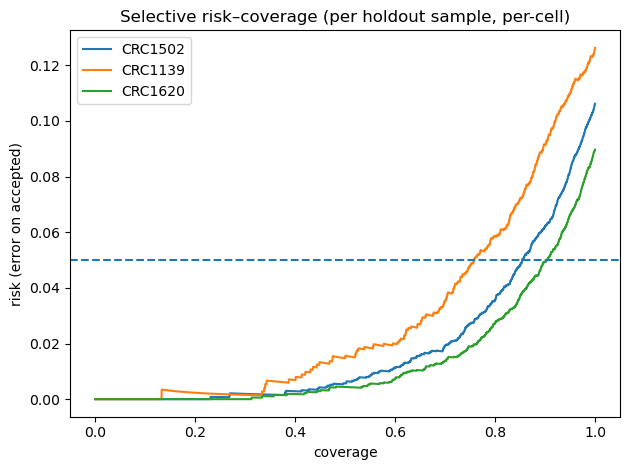

In [137]:
plt.figure()
for h in df_cells["holdout"].unique():
    d = df_cells[df_cells["holdout"] == h].copy()
    order = np.argsort(-d["margin"].values)
    err_sorted = (~d["correct"].values).astype(int)[order]
    k = np.arange(1, len(err_sorted)+1)
    cov = k / len(err_sorted)
    risk = np.cumsum(err_sorted) / k
    plt.plot(cov, risk, label=str(h))

plt.axhline(0.05, linestyle="--")
plt.xlabel("coverage")
plt.ylabel("risk (error on accepted)")
plt.title("Selective risk–coverage (per holdout sample, per-cell)")
plt.legend()
plt.tight_layout()
plt.show()


In [138]:
scaler_final = MaxAbsScaler()
X_kras_scaled = scaler_final.fit_transform(X)

rf_final = RandomForestClassifier(**rf_params)
rf_final.fit(X_kras_scaled, y)

print("RF trained on all KRAS. tau_final =", tau_final)


RF trained on all KRAS. tau_final = 0.07666666666666669


In [139]:
data_path='/mnt/cold2/snaketree/prj/PPH/local/share/data/saver_mat'
test_id=['CRC0322','CRC0542','CRC0327']
tratt_cercato=['cetux','CTX72h']
test=pd.DataFrame()
for file in os.listdir(data_path):
    sample_name=str.split(file,sep='_')[4]
    trattamento=str.split(file,sep='_')[5]
    if sample_name in test_id and trattamento in tratt_cercato:
        print(file)
        data=pd.read_csv(os.path.join(data_path,file),header=0,index_col=0)
        data=data.T
        data['sample']=sample_name
        data['cell_id']=data.index
        data['trattamento']=trattamento
        data.reset_index(drop=True,inplace=True)
        test=pd.concat([test,data])

filtered_annotated_saver_ribomito_CRC0322_cetux_1_log2_pc1_cpm.csv
filtered_annotated_saver_ribomito_CRC0327_cetux_2_log2_pc1_cpm.csv
filtered_annotated_saver_ribomito_CRC0542_CTX72h_1_log2_pc1_cpm.csv


In [140]:
from func_NT_cetux import *
dt=test
df_clean_dt, dup = strip_prefix_from_genes(dt, meta_cols=("cell_id","sample","trattamento"), sep=":", on_duplicate="first")
df_clean_dt = df_clean_dt.loc[:,to_keep]
df_clean_dt['uid']=df_clean_dt['sample']+df_clean_dt['trattamento']+'|'+df_clean_dt['cell_id']+'|'+df_clean_dt['trattamento']
df_clean_dt.head()
df_clean_dt.index=df_clean_dt['uid']
meta_cols_dt = ['uid','sample','cell_id','trattamento']
feature_cols = [c for c in df_clean_dt.columns if c not in meta_cols_dt]
X_dt = df_clean_dt[feature_cols].copy()
X_dt_scaled = scaler.transform(X_dt)

In [141]:
import numpy as np
import pandas as pd

def margin_score(probs):
    p_sorted = np.sort(probs, axis=1)
    return p_sorted[:, -1] - p_sorted[:, -2]

# 1) probabilità WT
probs_dt = rf_final.predict_proba(X_dt_scaled)   # oppure rf.predict_proba(...)
pred_dt  = probs_dt.argmax(axis=1)

# 2) score confidenza
maxprob_dt = probs_dt.max(axis=1)
margin_dt  = margin_score(probs_dt)

# 3) filtro con tau_final (calibrata sui KRAS)
accepted_dt = margin_dt >= tau_final

pred_dt_filt = pred_dt.copy()
pred_dt_filt[~accepted_dt] = -1   # -1 = Unknown

print("WT coverage (accepted):", accepted_dt.mean())
print("WT unknown:", (~accepted_dt).mean())


WT coverage (accepted): 0.9377740903164632
WT unknown: 0.0622259096835368


In [148]:
wt_pred_df = pd.DataFrame({
    "uid": df_clean_dt["uid"].values if "uid" in df_clean_dt.columns else df_clean_dt.index.values,
    "sample": df_clean_dt["sample"].values,
    "cell_id": df_clean_dt["cell_id"].values,
    "trattamento": df_clean_dt["trattamento"].values,
    "pred_cluster": pred_dt,
    "pred_cluster_filt": pred_dt_filt,
    "accepted": accepted_dt,
    "margin": margin_dt,
    "max_prob": maxprob_dt
}).set_index("uid")

wt_pred_df.head()
path_to_save='bbknn_cetux_KRAS/npcs=20__nwb=3__trim=None__res=0.3/prediction_wt_cetux/prediction_wt_cetux.csv'
wt_pred_df.to_csv(path_to_save)

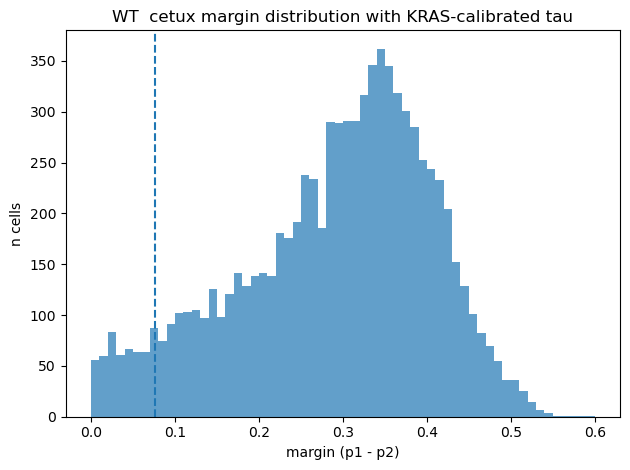

In [127]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(wt_pred_df["margin"], bins=60, alpha=0.7)
plt.axvline(tau_final, linestyle="--")
plt.xlabel("margin (p1 - p2)")
plt.ylabel("n cells")
plt.title("WT  cetux margin distribution with KRAS-calibrated tau")
plt.tight_layout()
plt.show()


In [123]:
import pandas as pd

# totali predetti per cluster
tot = (wt_pred_df
       .groupby(["sample","pred_cluster"])
       .size()
       .rename("n_total")
       .reset_index())

# rejected per cluster (accepted == False)
rej = (wt_pred_df.loc[~wt_pred_df["accepted"]]
       .groupby(["sample","pred_cluster"])
       .size()
       .rename("n_rejected")
       .reset_index())

summary = tot.merge(rej, on=["sample","pred_cluster"], how="left").fillna(0)
summary["n_rejected"] = summary["n_rejected"].astype(int)
summary["n_accepted"] = summary["n_total"] - summary["n_rejected"]

summary = summary.sort_values(["sample","pred_cluster"])
summary


,sample,pred_cluster,n_total,n_rejected,n_accepted
0,CRC0322,0,1811,41,1770
1,CRC0322,2,43,19,24
2,CRC0322,3,72,18,54
3,CRC0322,4,416,36,380
4,CRC0322,5,124,23,101
5,CRC0327,0,3174,78,3096
6,CRC0327,2,17,6,11
7,CRC0327,3,47,18,29
8,CRC0327,4,275,23,252
9,CRC0327,5,57,4,53


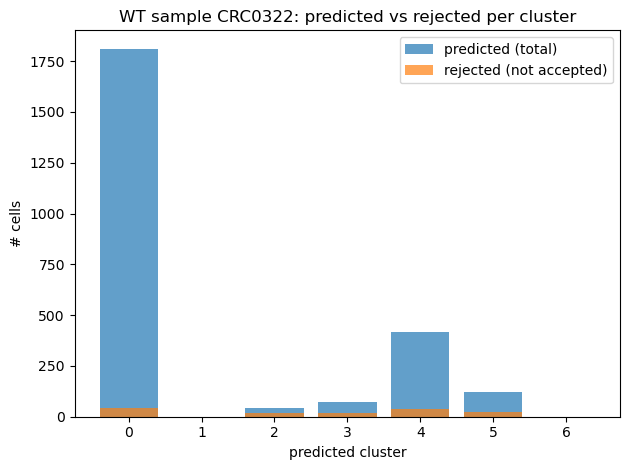

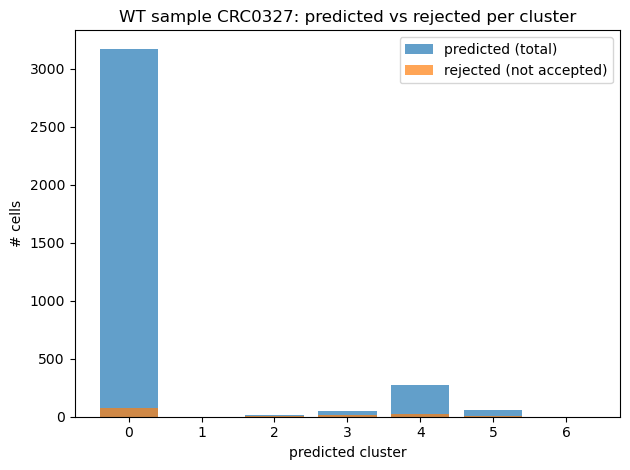

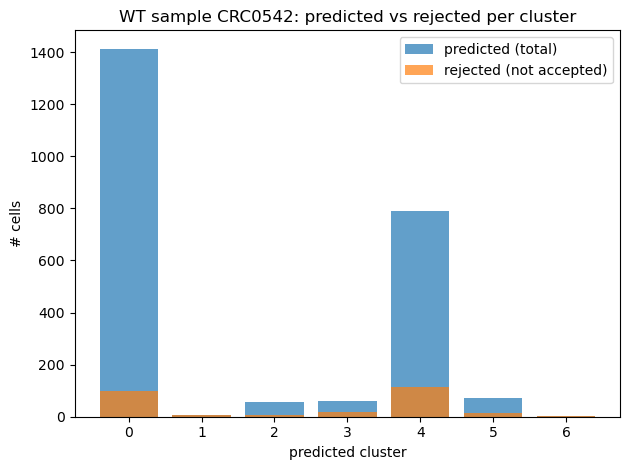

In [124]:
import numpy as np
import matplotlib.pyplot as plt

samples_wt = summary["sample"].unique()
clusters = sorted(summary["pred_cluster"].unique())

for s in samples_wt:
    df_s = summary[summary["sample"] == s].set_index("pred_cluster")
    df_s = df_s.reindex(clusters, fill_value=0)

    x = np.arange(len(clusters))

    plt.figure()
    # barra totale
    plt.bar(x, df_s["n_total"].values, alpha=0.7, label="predicted (total)")
    # barra rejected sovrapposta (parte scartata)
    plt.bar(x, df_s["n_rejected"].values, alpha=0.7, label="rejected (not accepted)")

    plt.xticks(x, clusters)
    plt.xlabel("predicted cluster")
    plt.ylabel("# cells")
    plt.title(f"WT sample {s}: predicted vs rejected per cluster")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [143]:
data_path='/mnt/cold2/snaketree/prj/PPH/local/share/data/saver_mat'
test_id=['CRC0322','CRC0542','CRC0327']
tratt_cercato=['NT','NT72h']
test_nt=pd.DataFrame()
for file in os.listdir(data_path):
    sample_name=str.split(file,sep='_')[4]
    trattamento=str.split(file,sep='_')[5]
    if sample_name in test_id and trattamento in tratt_cercato:
        print(file)
        data=pd.read_csv(os.path.join(data_path,file),header=0,index_col=0)
        data=data.T
        data['sample']=sample_name
        data['cell_id']=data.index
        data['trattamento']=trattamento
        data.reset_index(drop=True,inplace=True)
        test_nt=pd.concat([test_nt,data])

filtered_annotated_saver_ribomito_CRC0322_NT_1_3000_log2_pc1_cpm.csv
filtered_annotated_saver_ribomito_CRC0327_NT_2_log2_pc1_cpm.csv
filtered_annotated_saver_ribomito_CRC0542_NT72h_1_log2_pc1_cpm.csv


In [144]:
from func_NT_cetux import *
nt=test_nt
df_clean_nt, dup = strip_prefix_from_genes(nt, meta_cols=("cell_id","sample","trattamento"), sep=":", on_duplicate="first")
df_clean_nt = df_clean_nt.loc[:,to_keep]
df_clean_nt['uid']=df_clean_nt['sample']+df_clean_nt['trattamento']+'|'+df_clean_nt['cell_id']+'|'+df_clean_nt['trattamento']
df_clean_nt.index=df_clean_nt['uid']
meta_cols_nt = ['uid','sample','cell_id','trattamento']
feature_cols = [c for c in df_clean_nt.columns if c not in meta_cols_dt]
X_nt = df_clean_nt[feature_cols].copy()
X_nt_scaled = scaler.transform(X_nt)

In [145]:
import numpy as np
import pandas as pd

def margin_score(probs):
    p_sorted = np.sort(probs, axis=1)
    return p_sorted[:, -1] - p_sorted[:, -2]

probs_dt_nt = rf_final.predict_proba(X_nt_scaled)   # oppure rf.predict_proba(...)
pred_dt_nt  = probs_dt_nt.argmax(axis=1)


maxprob_dt_nt = probs_dt_nt.max(axis=1)
margin_dt_nt  = margin_score(probs_dt_nt)


accepted_dt_nt = margin_dt_nt >= tau_final

pred_dt_filt_nt = pred_dt_nt.copy()
pred_dt_filt_nt[~accepted_dt_nt] = -1  

print("WT coverage (accepted):", accepted_dt_nt.mean())
print("WT unknown:", (~accepted_dt_nt).mean())

WT coverage (accepted): 0.8132338308457712
WT unknown: 0.18676616915422886


In [149]:
wt_pred_df_nt = pd.DataFrame({
    "uid": df_clean_nt["uid"].values if "uid" in df_clean_nt.columns else df_clean_dt.index.values,
    "sample": df_clean_nt["sample"].values,
    "cell_id": df_clean_nt["cell_id"].values,
    "trattamento": df_clean_nt["trattamento"].values,
    "pred_cluster": pred_dt_nt,
    "pred_cluster_filt": pred_dt_filt_nt,
    "accepted": accepted_dt_nt,
    "margin": margin_dt_nt,
    "max_prob": maxprob_dt_nt
}).set_index("uid")

wt_pred_df_nt.head()

path_to_save='bbknn_cetux_KRAS/npcs=20__nwb=3__trim=None__res=0.3/prediction_wt_nt/prediction_wt_nt.csv'
wt_pred_df_nt.to_csv(path_to_save)

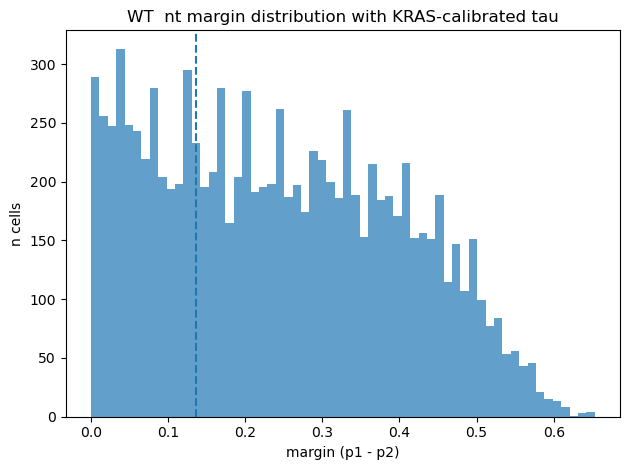

In [94]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(wt_pred_df_nt["margin"], bins=60, alpha=0.7)
plt.axvline(tau_final, linestyle="--")
plt.xlabel("margin (p1 - p2)")
plt.ylabel("n cells")
plt.title("WT  nt margin distribution with KRAS-calibrated tau")
plt.tight_layout()
plt.show()


In [95]:
import pandas as pd

# totali predetti per cluster
tot = (wt_pred_df_nt
       .groupby(["sample","pred_cluster"])
       .size()
       .rename("n_total")
       .reset_index())

# rejected per cluster (accepted == False)
rej = (wt_pred_df_nt.loc[~wt_pred_df_nt["accepted"]]
       .groupby(["sample","pred_cluster"])
       .size()
       .rename("n_rejected")
       .reset_index())

summary = tot.merge(rej, on=["sample","pred_cluster"], how="left").fillna(0)
summary["n_rejected"] = summary["n_rejected"].astype(int)
summary["n_accepted"] = summary["n_total"] - summary["n_rejected"]

summary = summary.sort_values(["sample","pred_cluster"])
summary


,sample,pred_cluster,n_total,n_rejected,n_accepted
0,CRC0322,0,214,123,91
1,CRC0322,1,898,151,747
2,CRC0322,2,404,224,180
3,CRC0322,3,434,206,228
4,CRC0322,4,66,49,17
5,CRC0322,5,890,239,651
6,CRC0327,0,662,190,472
7,CRC0327,1,308,138,170
8,CRC0327,2,815,275,540
9,CRC0327,3,982,304,678


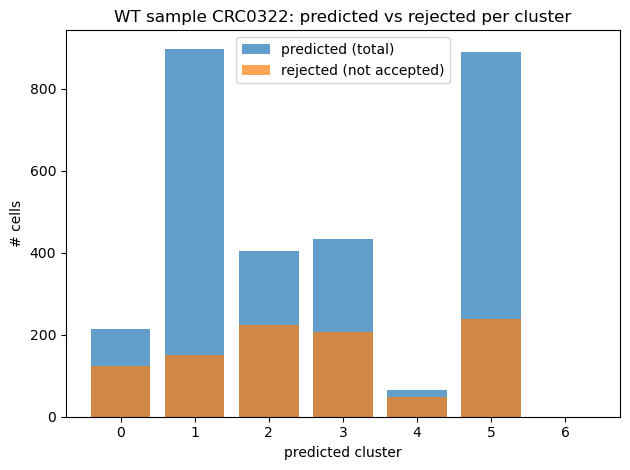

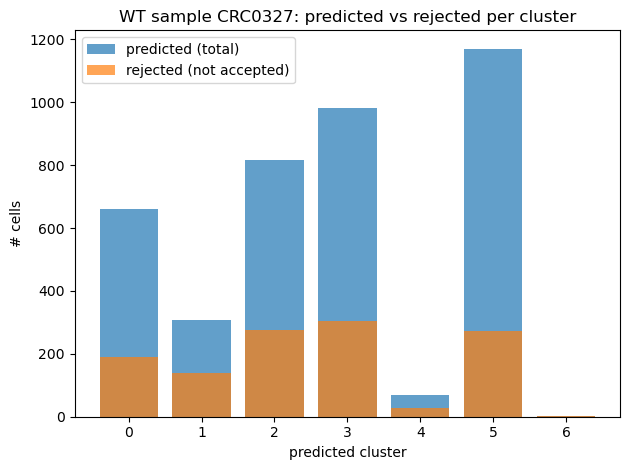

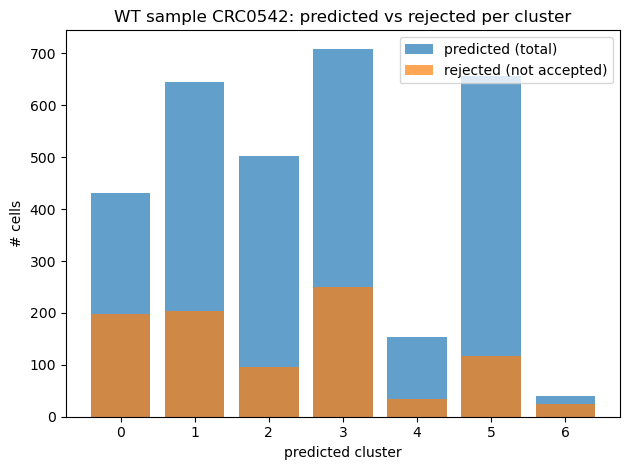

In [96]:
import numpy as np
import matplotlib.pyplot as plt

samples_wt = summary["sample"].unique()
clusters = sorted(summary["pred_cluster"].unique())

for s in samples_wt:
    df_s = summary[summary["sample"] == s].set_index("pred_cluster")
    df_s = df_s.reindex(clusters, fill_value=0)

    x = np.arange(len(clusters))

    plt.figure()
    # barra totale
    plt.bar(x, df_s["n_total"].values, alpha=0.7, label="predicted (total)")
    # barra rejected sovrapposta (parte scartata)
    plt.bar(x, df_s["n_rejected"].values, alpha=0.7, label="rejected (not accepted)")

    plt.xticks(x, clusters)
    plt.xlabel("predicted cluster")
    plt.ylabel("# cells")
    plt.title(f"WT sample {s}: predicted vs rejected per cluster")
    plt.legend()
    plt.tight_layout()
    plt.show()
